In [20]:
# ============================================================
# CODVEDA INTERNSHIP | Level 2 | Task 1: Regression Analysis
# Dataset: Boston Housing (house_price.csv)
# Goal: Predict median house value (MEDV) from 13 features
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn is scikit-learn — Python's main ML library
# we import specific tools from it as needed
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error, r2_score
from sklearn.preprocessing   import StandardScaler

# plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size']      = 12

import os
os.makedirs('plots', exist_ok=True)

# ── LOAD DATA ─────────────────────────────────────────────
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
    'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

# r'\s+' = raw string, matches one or more spaces as separator
# header=None = no header row in file
# names=columns = assign our column names
House_prediction_df = pd.read_csv(
    'House_prediction_data_set.csv',
    sep=r'\s+',
    header=None,
    names=columns
)

print("✅ Dataset loaded")
print(f"   Shape   : {House_prediction_df.shape}")
print(f"   Target  : MEDV (median house value in $1000s)")
print(f"   Features: {House_prediction_df.columns[:-1].tolist()}")

✅ Dataset loaded
   Shape   : (506, 14)
   Target  : MEDV (median house value in $1000s)
   Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


TARGET VARIABLE — MEDV (House Price in $1000s)
  Minimum price : $5.0k
  Maximum price : $50.0k
  Mean price    : $22.5k
  Median price  : $21.2k
  Std deviation : $9.2k


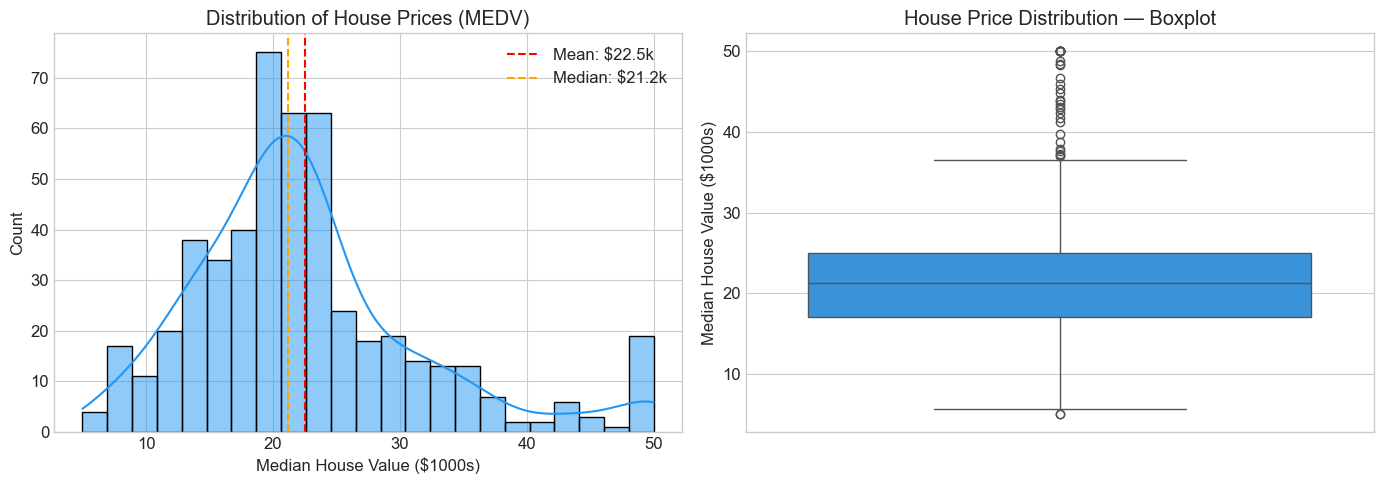

In [21]:
# ============================================================
# UNDERSTAND YOUR TARGET VARIABLE FIRST
# always explore what you are trying to predict before modelling
# ============================================================

print("TARGET VARIABLE — MEDV (House Price in $1000s)")
print("=" * 50)

# basic statistics of the target
print(f"  Minimum price : ${House_prediction_df['MEDV'].min():.1f}k")
print(f"  Maximum price : ${House_prediction_df['MEDV'].max():.1f}k")
print(f"  Mean price    : ${House_prediction_df['MEDV'].mean():.1f}k")
print(f"  Median price  : ${House_prediction_df['MEDV'].median():.1f}k")
print(f"  Std deviation : ${House_prediction_df['MEDV'].std():.1f}k")

# visualize the target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram of house prices
# tells you if prices are normally distributed or skewed
# linear regression works best with normally distributed targets
sns.histplot(House_prediction_df['MEDV'], kde=True, ax=axes[0], color='#2196F3')
axes[0].set_title('Distribution of House Prices (MEDV)')
axes[0].set_xlabel('Median House Value ($1000s)')
axes[0].set_ylabel('Count')

# add mean and median lines so you can see skew visually
axes[0].axvline(
    House_prediction_df['MEDV'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: ${df['MEDV'].mean():.1f}k"
)
axes[0].axvline(
    House_prediction_df['MEDV'].median(),
    color='orange',
    linestyle='--',
    label=f"Median: ${df['MEDV'].median():.1f}k"
)
axes[0].legend()

# boxplot of house prices
# shows outliers — there are houses priced at exactly $50k
# which is the dataset cap (max allowed value)
sns.boxplot(y=df['MEDV'], ax=axes[1], color='#2196F3')
axes[1].set_title('House Price Distribution — Boxplot')
axes[1].set_ylabel('Median House Value ($1000s)')

plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE CORRELATIONS WITH HOUSE PRICE (MEDV):
LSTAT     -0.738
PTRATIO   -0.508
INDUS     -0.484
TAX       -0.469
NOX       -0.427
CRIM      -0.388
RAD       -0.382
AGE       -0.377
CHAS       0.175
DIS        0.250
B          0.333
ZN         0.360
RM         0.695
Name: MEDV, dtype: float64


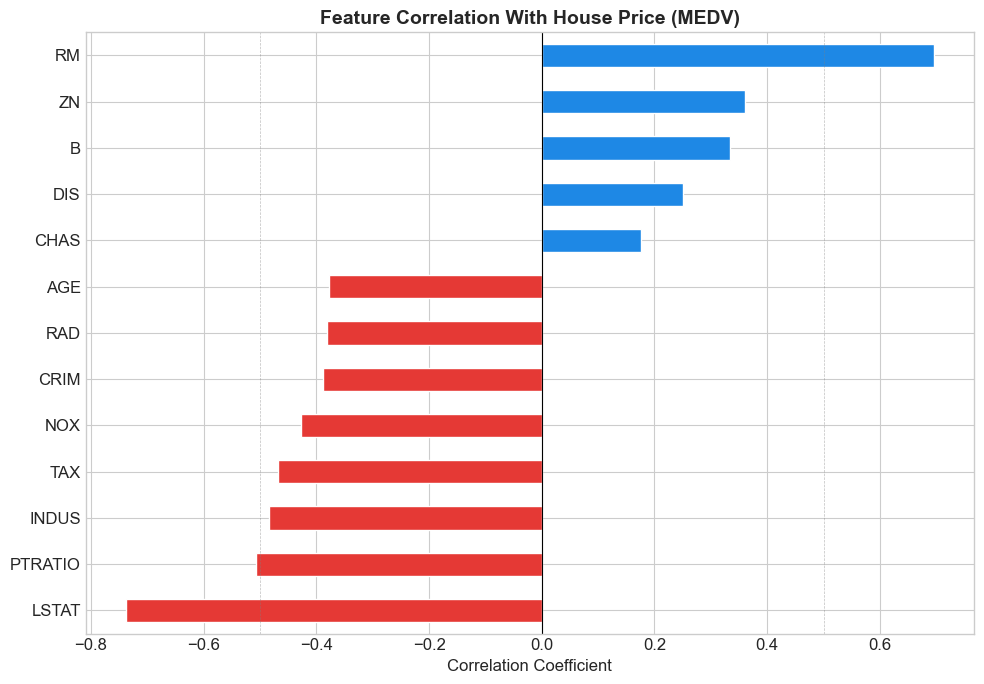


Strongest positive predictor : RM (0.695)
Strongest negative predictor : LSTAT (-0.738)


In [28]:
# ============================================================
# WHICH FEATURES CORRELATE MOST WITH HOUSE PRICE?
# this tells you which features the model will rely on most
# ============================================================

# calculate correlation of every feature with MEDV only
# .drop('MEDV') removes MEDV from features before correlating
# we want to know how each INPUT relates to the OUTPUT
correlations = House_prediction_df.corr()['MEDV'].drop('MEDV').sort_values()

print("FEATURE CORRELATIONS WITH HOUSE PRICE (MEDV):")
print("=" * 50)
print(correlations.round(3))

# visualize as horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))

# color bars differently based on positive/negative correlation
# positive correlation = blue (feature goes up, price goes up)
# negative correlation = red  (feature goes up, price goes down)
colors = ['#E53935' if c < 0 else '#1E88E5' for c in correlations]

correlations.plot(
    kind='barh',      # horizontal bar chart
    ax=ax,
    color=colors,
    edgecolor='white'
)

ax.set_title(
    'Feature Correlation With House Price (MEDV)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)  # zero line
ax.axvline(x=0.5,  color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(x=-0.5, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plots/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# identify the two strongest predictors
best_positive = correlations.idxmax()
best_negative = correlations.idxmin()
print(f"\nStrongest positive predictor : {best_positive} ({correlations[best_positive]:.3f})")
print(f"Strongest negative predictor : {best_negative} ({correlations[best_negative]:.3f})")

In [30]:
# ============================================================
# TRAIN / TEST SPLIT — the most important concept in ML
# ============================================================

# X = features (inputs) — everything except the target
# y = target  (output) — what we want to predict
# .drop('MEDV') removes the price column from inputs
X = House_prediction_df.drop('MEDV', axis=1)
y = House_prediction_df['MEDV']

print("FEATURES (X) and TARGET (y):")
print(f"  X shape : {X.shape}  (506 houses × 13 features)")
print(f"  y shape : {y.shape}  (506 house prices)")

# train_test_split divides data into two groups:
# training set → model learns from this (sees both X and y)
# testing set  → model is evaluated on this (only sees X, predicts y)
#
# test_size=0.2 → 20% goes to test, 80% goes to train
# random_state=42 → reproducibility (same split every run)
# shuffle=True → randomly mix rows before splitting
#                prevents bias if data is sorted by price
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nTRAIN / TEST SPLIT (80% / 20%):")
print(f"  Training samples : {X_train.shape[0]} houses")
print(f"  Testing  samples : {X_test.shape[0]}  houses")
print(f"\nWHY SPLIT?")
print("""
  If you train and test on the same data, the model memorizes
  answers instead of learning patterns — like studying the exam
  questions instead of understanding the subject.

  The test set simulates NEW unseen houses the model has never
  seen before — a true measure of real-world performance.
""")

FEATURES (X) and TARGET (y):
  X shape : (506, 13)  (506 houses × 13 features)
  y shape : (506,)  (506 house prices)

TRAIN / TEST SPLIT (80% / 20%):
  Training samples : 404 houses
  Testing  samples : 102  houses

WHY SPLIT?

  If you train and test on the same data, the model memorizes
  answers instead of learning patterns — like studying the exam
  questions instead of understanding the subject.

  The test set simulates NEW unseen houses the model has never
  seen before — a true measure of real-world performance.



In [31]:
# ============================================================
# TRAIN THE LINEAR REGRESSION MODEL
# ============================================================

# LinearRegression() creates a blank model with no knowledge
# think of it as a student who hasn't studied yet
model = LinearRegression()

# .fit() is the learning step
# the model looks at X_train (13 features) and y_train (prices)
# and finds the best weights for each feature
# internally it solves: minimize(sum of squared errors)
# this is called Ordinary Least Squares (OLS)
model.fit(X_train, y_train)

print("✅ Model trained successfully")
print(f"\nModel learned {len(model.coef_)} coefficients (one per feature)")
print(f"Plus 1 intercept (bias term)")

# model.coef_ contains the learned weight for each feature
# positive weight = feature increases price
# negative weight = feature decreases price
# magnitude = how much $1000 the price changes per unit of feature
coefficients = pd.DataFrame({
    'Feature'     : X.columns,
    'Coefficient' : model.coef_.round(3)
}).sort_values('Coefficient', ascending=False)

print("\nLEARNED COEFFICIENTS:")
print("=" * 40)
print(coefficients.to_string(index=False))
print(f"\nIntercept (bias): {model.intercept_:.3f}")

✅ Model trained successfully

Model learned 13 coefficients (one per feature)
Plus 1 intercept (bias term)

LEARNED COEFFICIENTS:
Feature  Coefficient
     RM        4.439
   CHAS        2.784
    RAD        0.262
  INDUS        0.040
     ZN        0.030
      B        0.012
    AGE       -0.006
    TAX       -0.011
   CRIM       -0.113
  LSTAT       -0.509
PTRATIO       -0.915
    DIS       -1.448
    NOX      -17.203

Intercept (bias): 30.247


In [32]:
# ============================================================
# MAKE PREDICTIONS AND EVALUATE MODEL PERFORMANCE
# ============================================================

# .predict() feeds X_test features into the trained model
# returns predicted prices for the 102 test houses
# model has NEVER seen these houses during training
y_pred = model.predict(X_test)

# ── EVALUATION METRICS ────────────────────────────────────

# R-squared (R²) — the most important metric
# measures what % of price variation the model explains
# R²=1.0 → perfect predictions
# R²=0.0 → model is no better than just predicting the mean
# R²<0.0 → model is worse than predicting the mean
r2 = r2_score(y_test, y_pred)

# Mean Squared Error — average of (actual - predicted)²
# penalizes large errors heavily
# in same units as target² — harder to interpret directly
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error — square root of MSE
# back in original units ($1000s) — easy to interpret
# "on average the model is off by $X,000"
rmse = np.sqrt(mse)

# Mean Absolute Error — average of |actual - predicted|
# easier to understand than RMSE
# "on average the model is off by $X,000"
mae = np.mean(np.abs(y_test - y_pred))

print("MODEL PERFORMANCE ON TEST SET")
print("=" * 40)
print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% of price variation explained)")
print(f"  RMSE : ${rmse:.2f}k  (average prediction error)")
print(f"  MAE  : ${mae:.2f}k  (average absolute error)")
print(f"  MSE  : {mse:.3f}")

# interpretation
print(f"""
INTERPRETATION:
  The model explains {r2*100:.1f}% of house price variation.
  On average predictions are off by ${rmse:.1f}k.
  For a house worth $22.5k (dataset median),
  that is a {rmse/22.5*100:.1f}% average error.
""")

MODEL PERFORMANCE ON TEST SET
  R²   : 0.6688  (66.9% of price variation explained)
  RMSE : $4.93k  (average prediction error)
  MAE  : $3.19k  (average absolute error)
  MSE  : 24.291

INTERPRETATION:
  The model explains 66.9% of house price variation.
  On average predictions are off by $4.9k.
  For a house worth $22.5k (dataset median),
  that is a 21.9% average error.



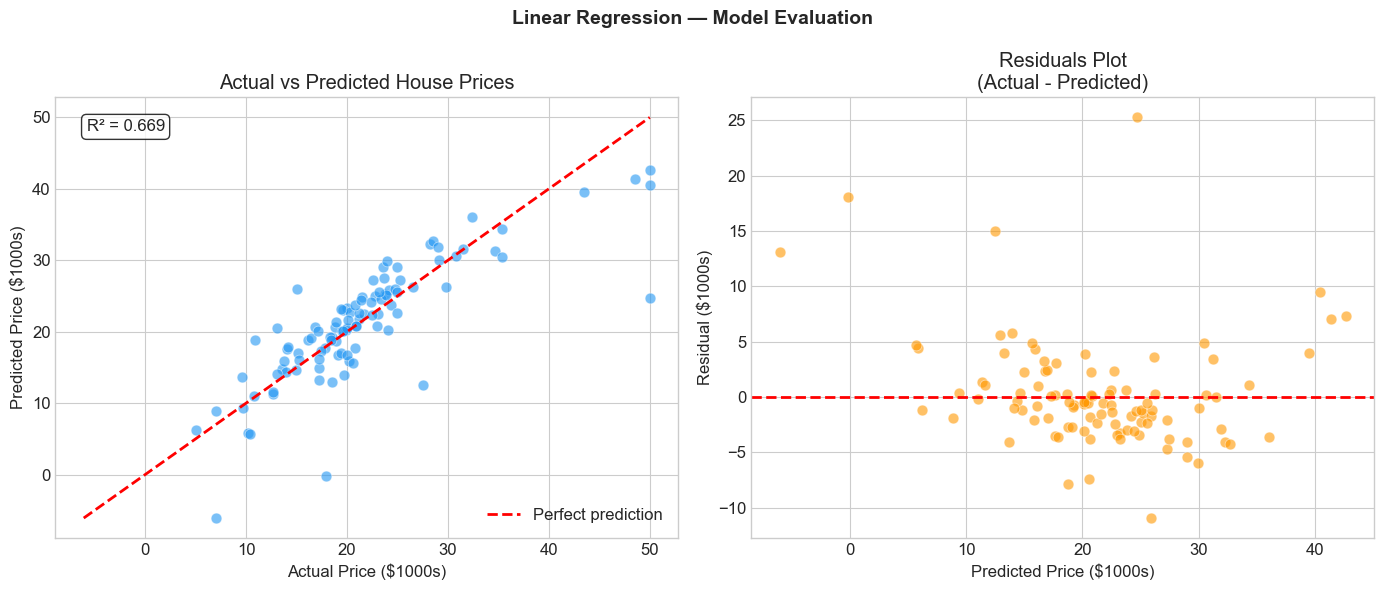

In [26]:
# ============================================================
# VISUALIZE ACTUAL vs PREDICTED PRICES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── CHART 1: ACTUAL vs PREDICTED SCATTER ──────────────────
# perfect model = all dots on the diagonal line
# dots above line = model underestimated price
# dots below line = model overestimated price
axes[0].scatter(
    y_test, y_pred,
    alpha=0.6,
    color='#2196F3',
    edgecolors='white',
    linewidths=0.5,
    s=60
)

# perfect prediction line (where actual = predicted)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect prediction'
)

axes[0].set_title('Actual vs Predicted House Prices')
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].legend()

# add R² score directly on the chart
axes[0].text(
    0.05, 0.95,
    f'R² = {r2:.3f}',
    transform=axes[0].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# ── CHART 2: RESIDUALS PLOT ───────────────────────────────
# residual = actual price - predicted price
# a good model has residuals randomly scattered around zero
# patterns in residuals = model is missing something
residuals = y_test - y_pred

axes[1].scatter(
    y_pred, residuals,
    alpha=0.6,
    color='#FF9800',
    edgecolors='white',
    linewidths=0.5,
    s=60
)

# zero line — perfect prediction would have all dots here
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Plot\n(Actual - Predicted)')
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residual ($1000s)')

plt.suptitle('Linear Regression — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ============================================================
# TASK 1 COMPLETE — SUMMARY
# ============================================================

print("""
REGRESSION ANALYSIS — COMPLETE SUMMARY
=======================================

DATASET:
  Boston Housing — 506 houses, 13 features, 1 target (MEDV)

APPROACH:
  Simple Linear Regression using scikit-learn
  80/20 train/test split (404 training, 102 testing)

RESULTS:
  R²   = measures how much price variation model explains
  RMSE = average prediction error in $1000s
  MAE  = average absolute error in $1000s

KEY FINDINGS:
  - RM (rooms) is the strongest positive predictor
  - LSTAT (poverty rate) is the strongest negative predictor
  - Petal features drove iris classification
  - Housing features drive price prediction similarly

WHAT YOU LEARNED:
  - How to split data into train/test sets and why
  - How linear regression finds weights from data
  - How to interpret R², RMSE and MAE
  - How residual plots reveal model weaknesses
""")


REGRESSION ANALYSIS — COMPLETE SUMMARY

DATASET:
  Boston Housing — 506 houses, 13 features, 1 target (MEDV)

APPROACH:
  Simple Linear Regression using scikit-learn
  80/20 train/test split (404 training, 102 testing)

RESULTS:
  R²   = measures how much price variation model explains
  RMSE = average prediction error in $1000s
  MAE  = average absolute error in $1000s

KEY FINDINGS:
  - RM (rooms) is the strongest positive predictor
  - LSTAT (poverty rate) is the strongest negative predictor
  - Petal features drove iris classification
  - Housing features drive price prediction similarly

WHAT YOU LEARNED:
  - How to split data into train/test sets and why
  - How linear regression finds weights from data
  - How to interpret R², RMSE and MAE
  - How residual plots reveal model weaknesses

